[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/probability_statistics/03_random_variables_and_distribution_functions/first_principles.ipynb)

# Module 03 — Random Variables and Distribution Functions

## 1. Why This Module Exists

A probability space $(\Omega, \mathcal{F}, P)$ describes *outcomes*, but science and engineering work with *numbers*: the count of heads, the voltage of a noisy sensor, the return of a portfolio. A random variable is the formal device that converts outcomes into numbers:

$$
X: \Omega \to \mathbb{R}, \qquad \omega \mapsto X(\omega).
$$

Crucially, $X$ itself is a perfectly deterministic function — a fixed measurement rule. The randomness enters only through which outcome $\omega$ the experiment delivers. Once numbers flow, probability becomes analysis: events like $\{X \le x\}$ have probabilities, and tracking them for every threshold $x$ produces the cumulative distribution function, the complete numerical fingerprint of $X$.

Three descriptions of a distribution circulate: PMF (discrete), PDF (continuous), CDF (always). Only the CDF is universal, and Module 03 is built around that fact. Everything downstream — naming the standard discrete and continuous families, taking expectations, proving limit theorems — presumes that "the law of $X$" is a well-defined object living on $\mathbb{R}$ rather than on the unnameable space $\Omega$. This module builds that object, characterizes exactly which functions can be one, and shows how to move a law through a transformation and how to manufacture a sample of it from uniform noise.

The payoff is immediate and computational. Every random number a GPU generates flows through an inverse-CDF or transformation algorithm; normalizing flows in deep generative modelling are the change-of-variables formula turned into an architecture; quantile functions underpin value-at-risk in finance and calibrated uncertainty in machine learning.

## 2. Intuition

Picture the CDF as a *water level*. Sweep a threshold $x$ from $-\infty$ to $+\infty$ and record how much probability mass has been swept past. The level starts at $0$, never falls, and ends at $1$. Everything a distribution can do shows up in the shape of that climb:

- **A vertical jump** means a lump of mass sits at a single point — an atom. The jump height *is* $P(X = x)$.
- **A smooth slope** means mass is spread out; the slope *is* the density $f_X$. A steep slope means a lot of mass per unit length, which is why a density may exceed $1$ while probabilities never do.
- **A flat stretch** means a region the variable never visits.

The three canonical shapes are drawn below: a pure staircase (discrete), a staircase-plus-slope (mixed — daily rainfall has an atom at zero and a continuous positive part), and the strange third possibility, a CDF that is continuous everywhere yet whose slope is zero almost everywhere. That last curve, the Cantor "devil's staircase", climbs from $0$ to $1$ while standing still on a set of full length; it is the visual proof that "continuous CDF" and "has a density" are different statements. Definition 3.5 and Theorem 4.2 make that precise.

Two operations then generate the whole computational toolkit. Reading the CDF *forwards* answers probability questions, $P(a \lt X \le b) = F(b) - F(a)$. Reading it *backwards*, through the quantile function $F^{-1}$, converts uniform noise into a sample of any law at all — and, run the other way, converts a sample of any continuous law back into uniform noise. Those are the sampling and calibration directions of Theorem 4.3.

Setup cell: the plotting defaults and the single random generator used by every later cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy import stats

The figure below draws the three shapes a CDF can take: pure jumps, jumps plus a slope, and the
singular case with no jumps and no slope. All three satisfy the same three conditions of
Theorem 4.1, which is why the CDF — not the PMF or PDF — is the universal object.

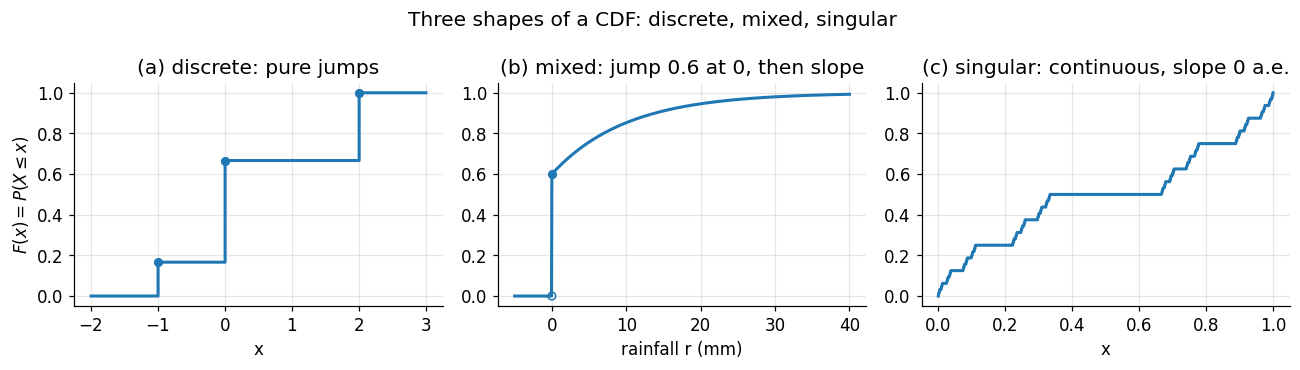

Cantor CDF at 1/3, 1/2, 2/3, 1: [0.5 0.5 0.5 1. ]


In [2]:
def cantor_cdf(x, n_digits=24):
    """Devil's staircase: read base-3 digits, halve them, stop at the first digit 1."""
    x = np.clip(np.asarray(x, dtype=float), 0.0, 1.0)
    F = np.zeros_like(x)
    live = np.ones(x.shape, dtype=bool)
    t = x.copy()
    for k in range(1, n_digits + 1):
        d = np.clip(np.floor(t * 3.0).astype(int), 0, 2)
        t = t * 3.0 - d
        F[live & (d >= 1)] += 2.0 ** (-k)
        live &= (d != 1)
    return F

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.4))

# (a) discrete: atoms at -1, 0, 2 with masses 1/6, 1/2, 1/3
atoms = np.array([-1.0, 0.0, 2.0])
masses = np.array([1 / 6, 1 / 2, 1 / 3])
gd = np.linspace(-2.0, 3.0, 1000)
Fd_grid = np.cumsum(np.append(0.0, masses))[np.searchsorted(atoms, gd, side="right")]
axes[0].step(gd, Fd_grid, where="post", lw=2)
axes[0].scatter(atoms, np.cumsum(masses), zorder=3, s=25)
axes[0].set_title("(a) discrete: pure jumps")

# (b) mixed: atom of mass 0.6 at 0, then Exponential(1/10) mass 0.4
gm = np.linspace(-5.0, 40.0, 1000)
Fm = np.where(gm < 0, 0.0, 0.6 + 0.4 * (1 - np.exp(-np.clip(gm, 0, None) / 10)))
axes[1].plot(gm, Fm, lw=2)
axes[1].scatter([0.0], [0.6], zorder=3, s=25)
axes[1].scatter([0.0], [0.0], zorder=3, s=25, facecolors="none", edgecolors="C0")
axes[1].set_title("(b) mixed: jump 0.6 at 0, then slope")

# (c) singular: Cantor CDF
gc = np.linspace(0.0, 1.0, 4001)
axes[2].plot(gc, cantor_cdf(gc), lw=2)
axes[2].set_title("(c) singular: continuous, slope 0 a.e.")

for ax, xl in zip(axes, ["x", "rainfall r (mm)", "x"]):
    ax.set_xlabel(xl)
    ax.set_ylim(-0.05, 1.05)
axes[0].set_ylabel(r"$F(x) = P(X \leq x)$")
fig.suptitle("Three shapes of a CDF: discrete, mixed, singular")
plt.tight_layout()
plt.show()

print("Cantor CDF at 1/3, 1/2, 2/3, 1:", cantor_cdf(np.array([1 / 3, 0.5, 2 / 3, 1.0])))

Panel (a) is a staircase whose risers are the point masses; panel (b) shows a right-continuous jump
of height $0.6$ at $r = 0$ (filled dot on, open dot off) followed by a smooth exponential climb;
panel (c) never jumps yet has zero slope off a set of length zero. The printed values
$F(1/3) = F(1/2) = F(2/3) = 1/2$ confirm the middle-third plateau. Panels (a) and (b) are the
corners $(a,b,c) = (1,0,0)$ and $(0.6, 0.4, 0)$ of Theorem 4.2; panel (c) is the corner $(0,0,1)$.

## 3. Definitions

**Definition 3.1 (Random Variable / Measurability).** Given $(\Omega, \mathcal{F}, P)$, a function $X: \Omega \to \mathbb{R}$ is a *random variable* if for every $x \in \mathbb{R}$,

$$
\{X \le x\} = \{\omega \in \Omega : X(\omega) \le x\} \in \mathcal{F}.
$$

Measurability guarantees that the events we ask about actually have probabilities. Because the sets $(-\infty, x]$ generate $\mathcal{B}(\mathbb{R})$, this implies $\{X \in B\} \in \mathcal{F}$ for every Borel set $B$.

**Definition 3.2 (Induced Law / Pushforward).** The *distribution* (law) of $X$ is the pushforward measure on $(\mathbb{R}, \mathcal{B})$:

$$
P_X(B) = P(X \in B) = P\left(X^{-1}(B)\right), \qquad B \in \mathcal{B}(\mathbb{R}).
$$

$P_X$ is itself a probability measure: countable additivity transfers because preimages preserve disjoint unions. The abstract space is now dispensable, and all computation happens on $\mathbb{R}$.

**Definition 3.3 (Cumulative Distribution Function).** The *CDF* of $X$ is

$$
F_X(x) = P(X \le x), \qquad x \in \mathbb{R}.
$$

We write $F(x^-) = \lim_{y \uparrow x} F(y)$ for the left limit, which exists everywhere by monotonicity.

**Definition 3.4 (Discrete Random Variable / PMF).** $X$ is *discrete* if there is a countable set $\{x_1, x_2, \ldots\}$ with $P(X \in \{x_1, x_2, \ldots\}) = 1$. Its *probability mass function* is

$$
p_X(x) = P(X = x), \qquad p_X(x) \ge 0, \qquad \sum_i p_X(x_i) = 1,
$$

and the CDF is the staircase $F_X(x) = \sum_{x_i \le x} p_X(x_i)$.

**Definition 3.5 (Absolutely Continuous Random Variable / PDF).** $X$ is *absolutely continuous* if there exists $f_X \ge 0$ with

$$
F_X(x) = \int_{-\infty}^{x} f_X(t)\,dt \quad \text{for all } x,
$$

in which case $f_X = F_X'$ at every point where $F_X$ is differentiable and $\int_{-\infty}^{\infty} f_X(t)\,dt = 1$. Then $P(X = x) = 0$ for every $x$, and for any $a \le b$,

$$
P(a \le X \le b) = \int_a^b f_X(t)\,dt = F_X(b) - F_X(a).
$$

A density is *not* a probability: $f_X(x) \gt 1$ is legal wherever mass is concentrated in a short interval — $\text{Unif}(0, 0.1)$ has $f_X = 10$.

**Definition 3.6 (Singular Continuous Law).** $X$ is *singular continuous* if $F_X$ is continuous (no atoms) yet $F_X' = 0$ Lebesgue-almost everywhere; equivalently, $P_X$ assigns full mass to a Borel set of Lebesgue measure zero while charging no single point. The Cantor law of panel (c) in Section 2 is the standard example.

**Definition 3.7 (Quantile Function).** The *quantile function* (generalized inverse CDF) is

$$
F_X^{-1}(u) = \inf\{x \in \mathbb{R} : F_X(x) \ge u\}, \qquad u \in (0, 1).
$$

The infimum handles flat stretches and jumps of $F$; when $F$ is continuous and strictly increasing on its support, $F^{-1}$ is the ordinary inverse. The median is $F^{-1}(0.5)$; value-at-risk at level $\alpha$ is the tail quantile $F^{-1}(\alpha)$.

**Definition 3.8 (Survival Function and Hazard Rate).** The *survival function* is $S(x) = P(X \gt x) = 1 - F(x)$. If $X$ is absolutely continuous with density $f$ and $S(x) \gt 0$, its *hazard rate* is

$$
h(x) = \frac{f(x)}{S(x)},
$$

the instantaneous failure rate given survival to $x$: $h(x)\,dx \approx P(x \lt X \le x + dx \mid X \gt x)$. Since $h = -\frac{d}{dx}\ln S$ and $S(0) = 1$ for a lifetime supported on $[0, \infty)$, the hazard determines the law through $S(x) = \exp\left(-\int_0^x h(s)\,ds\right)$.

## 4. Main Results

### Theorem 4.1 (Characterization of CDFs)

A function $F: \mathbb{R} \to [0,1]$ is the CDF of some random variable **if and only if**

1. $F$ is non-decreasing;
2. $\lim_{x \to -\infty} F(x) = 0$ and $\lim_{x \to +\infty} F(x) = 1$;
3. $F$ is right-continuous: $\lim_{y \downarrow x} F(y) = F(x)$.

Moreover, in that case $P(X = x) = F(x) - F(x^-)$, so $F$ is continuous at $x$ exactly when $x$ carries no atom, and $F$ has at most countably many discontinuities.

**Why each hypothesis is needed.** *Monotonicity* is forced by $\{X \le x\} \subseteq \{X \le y\}$ for $x \le y$; without it some interval would receive negative probability, since $P(a \lt X \le b) = F(b) - F(a)$. *The two limits* encode that $P$ is a probability measure with total mass $1$ and no mass escaping to $\pm\infty$; a function climbing only to $1/2$ describes a sub-probability. *Right-continuity* is not cosmetic: it is exactly the convention $F(x) = P(X \le x)$ rather than $P(X \lt x)$, and it is what makes the jump at $x$ equal $P(X = x)$; the left-continuous variant $x \mapsto P(X \lt x)$ satisfies 1 and 2 but is a different function at every atom.

$$
\boxed{F \text{ non-decreasing},\; F(-\infty) = 0,\; F(+\infty) = 1,\; F \text{ right-continuous} \iff F \text{ is a CDF}}
$$

**Interpretation.** The three conditions are not merely necessary bookkeeping — they are a complete specification. Any curve you can draw with those three properties *is* the distribution of an actual random variable, and Proof 5.1 builds that variable explicitly on the unit interval. Consequently a distribution may be defined by writing down a CDF, with no reference to any underlying $\Omega$; this is the licence used every time a textbook introduces a law "by its CDF".

### Theorem 4.2 (Lebesgue Decomposition of a CDF; cited, not proved here)

Every CDF $F$ decomposes uniquely as

$$
F = a\,F_{\text{disc}} + b\,F_{\text{ac}} + c\,F_{\text{sing}}, \qquad a + b + c = 1, \quad a, b, c \ge 0,
$$

where $F_{\text{disc}}$ is a pure-jump CDF supported on countably many atoms, $F_{\text{ac}}(x) = \int_{-\infty}^{x} f$ for some density $f$, and $F_{\text{sing}}$ is continuous with $F_{\text{sing}}' = 0$ almost everywhere.

**Why the hypotheses are trivial and the content is not.** No hypothesis beyond "$F$ is a CDF" is needed; the work is in the conclusion. The atomic split (Proof 5.2) is elementary. Splitting the remaining *continuous* part into absolutely continuous plus singular requires the Radon-Nikodym theorem, which is beyond this module's prerequisites: see Billingsley, *Probability and Measure*, 3rd ed., §31 (Theorem 31.8, p. 415) or Folland, *Real Analysis*, 2nd ed., §3.2 (Theorem 3.8). Proof 5.2 proves in full the strongest special case available here: $F = a F_{\text{disc}} + (1-a) F_{\text{cont}}$ with $F_{\text{cont}}$ continuous.

**Interpretation.** Discrete and absolutely continuous laws are two corners $(1,0,0)$ and $(0,1,0)$ of a two-dimensional simplex, not an exhaustive dichotomy. The mixed rainfall law of Section 2 sits on the edge $(0.6, 0.4, 0)$; the Cantor law sits at the third corner $(0,0,1)$. "Is it discrete or continuous?" is therefore the wrong first question about a distribution — "what is its CDF?" is the right one.

### Theorem 4.3 (Inverse Transform and Probability Integral Transform)

Let $F$ be a CDF and $F^{-1}$ its quantile function (Definition 3.7).

1. **Sampling direction.** If $U \sim \text{Unif}(0,1)$ then $X = F^{-1}(U)$ has CDF $F$ — for *any* $F$, discrete, continuous, mixed or singular.
2. **Calibration direction.** If $X$ has CDF $F$ and $F$ is **continuous**, then $U = F(X) \sim \text{Unif}(0,1)$.

**Why each hypothesis is needed.** Part 1 needs only that $F^{-1}$ be the *generalized* inverse: the infimum in Definition 3.7 is what keeps the statement true across flat stretches (where the ordinary inverse is multivalued) and jumps (where it is undefined). Part 2 genuinely needs continuity of $F$: if $X$ is a fair coin coded as $\{0,1\}$ then $F(X)$ takes only the two values $0.5$ and $1$, which is as far from uniform as a two-point law can be. Continuity is exactly what guarantees that every level $u \in (0,1)$ is attained by $F$.

$$
\boxed{U \sim \text{Unif}(0,1) \implies F^{-1}(U) \sim F; \qquad F \text{ continuous} \implies F(X) \sim \text{Unif}(0,1)}
$$

**Interpretation.** One uniform stream suffices for all of simulation: the quantile function is a universal adapter from uniform noise to any target law. Run backwards, the same statement is a test: if a forecaster's predictive CDFs $F_t$ were correct, the numbers $F_t(y_t)$ computed on realized outcomes $y_t$ would be uniform, so a non-flat histogram of those numbers is direct evidence of mis-calibration. Section 7 exhibits both directions numerically.

### Theorem 4.4 (Change of Variables, One Dimension)

Let $X$ have density $f_X$ and let $g$ be strictly monotone and continuously differentiable with $g' \ne 0$ on an open set containing the support of $X$. Then $Y = g(X)$ has density

$$
f_Y(y) = f_X\left(g^{-1}(y)\right) \left\lvert \frac{d}{dy} g^{-1}(y) \right\rvert .
$$

If $g$ is only piecewise monotone, with the support split into intervals $I_1, \ldots, I_m$ on which $g$ restricts to a strictly monotone $C^1$ bijection $g_j$, then

$$
f_Y(y) = \sum_{j:\, y \in g(I_j)} f_X\left(g_j^{-1}(y)\right) \left\lvert \frac{d}{dy} g_j^{-1}(y) \right\rvert .
$$

**Why each hypothesis is needed.** *Strict monotonicity* makes $g^{-1}$ single-valued, so the event $\{g(X) \le y\}$ is an interval in $x$; without it, as for $g(x) = x^2$, one $y$ has two preimages and a single term undercounts the mass — hence the branch sum. *$g' \ne 0$* keeps $g^{-1}$ differentiable; at a critical point the inverse has infinite slope and the density blows up (Proof 5.5 shows the $\chi^2_1$ singularity at $0$, which is integrable but unbounded). *A density for $X$* is required at all: if $X$ is discrete the correct statement is $p_Y(y) = \sum_{x: g(x) = y} p_X(x)$, with no Jacobian.

**Interpretation.** Densities are mass per unit length, so a map that stretches the axis must dilute them; the Jacobian factor is that bookkeeping and nothing more. Dropping it does not merely perturb the answer, it destroys normalization — Section 7 measures exactly how much.

### Theorem 4.5 (Change of Variables, $d$ Dimensions)

Let $X$ be a random vector on $\mathbb{R}^d$ with joint density $f_X$, and let $g$ be a diffeomorphism from an open set containing the support of $X$ onto its image — that is, $g$ is injective, $C^1$, and $\det J_g \ne 0$ throughout. Then $Y = g(X)$ has joint density

$$
f_Y(y) = f_X\left(g^{-1}(y)\right)\left\lvert \det J_{g^{-1}}(y) \right\rvert = \frac{f_X\left(g^{-1}(y)\right)}{\left\lvert \det J_g\left(g^{-1}(y)\right)\right\rvert}.
$$

**Why each hypothesis is needed.** *Injectivity on the support* is what makes $g^{-1}$ single-valued, exactly as in Theorem 4.4; for non-injective $g$ one sums over branches. *$\det J_g \ne 0$* is the multivariate version of $g' \ne 0$ and is what the inverse function theorem needs to produce a differentiable $g^{-1}$. Taking $d = 1$ collapses $\det J_{g^{-1}}$ to $\lvert (g^{-1})' \rvert$ and recovers Theorem 4.4.

**Interpretation.** $\lvert \det J \rvert$ is the local volume-scaling factor of $g$; a map that doubles volumes halves the density. This single line is the engine of normalizing flows (Section 8) and of the Box-Muller construction, and it explains why flow architectures are designed to keep $\det J_g$ triangular and therefore cheap.

### Theorem 4.6 (Memoryless Characterization of the Exponential)

Let $X \gt 0$ have survival function $S(x) = P(X \gt x)$ that is right-continuous with $S(0) = 1$ and $S(x) \gt 0$ for all $x$. Then

$$
S(s + t) = S(s)\,S(t) \quad \text{for all } s, t \ge 0 \iff S(x) = e^{-\lambda x} \text{ for some } \lambda \ge 0,
$$

that is, $X$ is exponential; equivalently $X$ has constant hazard rate $h \equiv \lambda$ in the sense of Definition 3.8.

**Why each hypothesis is needed.** *Right-continuity* rules out the pathological non-measurable solutions of Cauchy's functional equation — without a regularity assumption, $\ln S$ can be an additive but wildly discontinuous function built from a Hamel basis. *$S(x) \gt 0$ for all $x$* forbids a law with bounded support; if $S$ vanished at some $x_0$ the multiplicative identity would force $S \equiv 0$ on $[x_0, \infty)$ and the logarithm would be undefined. *$S(0) = 1$* fixes the law on $(0, \infty)$, excluding an atom at $0$.

**Interpretation.** Constant hazard means a used component is stochastically as good as new; this is the only continuous lifetime law with that property, which is why every non-constant hazard model (Weibull wear-out, bathtub curves) is a deliberate departure from the exponential.

### Summary of Section 4

| Object | Formula | Governing result |
|---|---|---|
| CDF | $F(x) = P(X \le x)$ | Theorem 4.1 |
| Interval probability | $P(a \lt X \le b) = F(b) - F(a)$ | Theorem 4.1 |
| Atom / jump | $P(X = x) = F(x) - F(x^-)$ | Theorem 4.1 |
| Decomposition | $F = aF_{\text{disc}} + bF_{\text{ac}} + cF_{\text{sing}}$ | Theorem 4.2 |
| PDF | $f = F'$ with $\int f = 1$; may exceed $1$ | Definition 3.5 |
| Quantile | $F^{-1}(u) = \inf\{x : F(x) \ge u\}$ | Definition 3.7 |
| Inverse transform | $F^{-1}(U) \sim F$ for $U \sim \text{Unif}(0,1)$ | Theorem 4.3 |
| PIT | $F(X) \sim \text{Unif}(0,1)$ when $F$ is continuous | Theorem 4.3 |
| Change of variables | $f_Y(y) = f_X(g^{-1}(y))\left\lvert \tfrac{d g^{-1}}{dy} \right\rvert$ | Theorem 4.4 |
| Jacobian in $\mathbb{R}^d$ | $f_Y(y) = f_X(g^{-1}(y))\left\lvert \det J_{g^{-1}}(y)\right\rvert$ | Theorem 4.5 |
| Hazard inversion | $S(x) = \exp\left(-\int_0^x h\right)$ | Definition 3.8 |

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

**Necessity.** Let $X$ be a random variable and $F(x) = P(X \le x)$.

*Monotone*: for $x \le y$, $\{X \le x\} \subseteq \{X \le y\}$, so $F(x) \le F(y)$ by monotonicity of $P$.

*Limits*: take any sequence $x_n \downarrow -\infty$. The events $A_n = \{X \le x_n\}$ decrease with $\bigcap_n A_n = \emptyset$, because no real value lies below every $x_n$; continuity of measure from above gives $F(x_n) \to P(\emptyset) = 0$. Similarly $\{X \le x_n\} \uparrow \Omega$ as $x_n \uparrow \infty$, so $F(x_n) \to 1$. Monotonicity upgrades sequential limits to the full limits.

*Right-continuity*: for $y_n \downarrow x$ the events $\{X \le y_n\}$ decrease to $\bigcap_n \{X \le y_n\} = \{X \le x\}$ — the intersection retains the endpoint, which is exactly why continuity holds from the right and not the left. Continuity from above gives $F(y_n) \downarrow F(x)$.

*Jump formula*: for $y_n \uparrow x$ we get $\{X \le y_n\} \uparrow \{X \lt x\}$, hence $F(x^-) = P(X \lt x)$ and $P(X = x) = F(x) - F(x^-)$. At most $n$ atoms can have mass exceeding $1/n$, so the atoms — equivalently the discontinuities — form a countable set.

**Sufficiency (existence).** Let $F$ satisfy 1-3. Put $\Omega = (0,1)$, $\mathcal{F} = \mathcal{B}((0,1))$, $P$ the Lebesgue measure, and define

$$
X(\omega) = F^{-1}(\omega) = \inf\{x : F(x) \ge \omega\}.
$$

The set $\{x : F(x) \ge \omega\}$ is nonempty by hypothesis 2 and bounded below for the same reason, so $X(\omega)$ is a finite real number for every $\omega \in (0,1)$; $X$ is non-decreasing in $\omega$ and therefore Borel measurable, so it is a random variable.

*Galois inequality.* For all $\omega \in (0,1)$ and $x \in \mathbb{R}$,

$$
F^{-1}(\omega) \le x \iff \omega \le F(x).
$$

($\Leftarrow$) If $\omega \le F(x)$ then $x \in \{t : F(t) \ge \omega\}$, so the infimum $F^{-1}(\omega)$ is at most $x$. ($\Rightarrow$) Let $x_0 = F^{-1}(\omega) \le x$. By definition of the infimum there are $t_n \downarrow x_0$ with $F(t_n) \ge \omega$; right-continuity (hypothesis 3) gives $F(x_0) = \lim_n F(t_n) \ge \omega$, and monotonicity (hypothesis 1) gives $F(x) \ge F(x_0) \ge \omega$. Note where each hypothesis entered: right-continuity supplies $F(F^{-1}(\omega)) \ge \omega$, monotonicity transports it to $x$.

Therefore, for every $x$,

$$
P(X \le x) = P\left(\{\omega \in (0,1) : \omega \le F(x)\}\right) = F(x),
$$

the last equality because Lebesgue measure of $(0, F(x)]$ is $F(x)$ and $F(x) \in [0,1]$. So $F$ is the CDF of this $X$. $\blacksquare$

**Remark.** The construction is the Skorokhod representation and doubles as Proof 5.3; Exercise L3.3 extends it to a whole family $F_1, F_2, \ldots$ realized simultaneously on the same $\omega$.

### Proof 5.2 (of Theorem 4.2, atomic part in full)

**Claim.** Every CDF $F$ splits uniquely as $F = a F_{\text{disc}} + (1-a) F_{\text{cont}}$ with $F_{\text{disc}}$ a pure-jump CDF, $F_{\text{cont}}$ continuous, and $a \in [0,1]$.

**Proof.** Let $D = \{x : F(x) \gt F(x^-)\}$ be the set of atoms, countable by Proof 5.1, with masses $p_x = F(x) - F(x^-)$. Set $a = \sum_{x \in D} p_x \le 1$ — the series has non-negative terms and its partial sums are bounded by $1$ because finitely many disjoint atoms carry total mass at most $1$, so it converges. Define

$$
J(x) = \sum_{t \in D,\, t \le x} p_t , \qquad G(x) = F(x) - J(x).
$$

$J$ is non-decreasing, right-continuous (dominated convergence on the countable sum) with $J(-\infty)=0$, $J(+\infty)=a$, and its jump at each $t \in D$ is exactly $p_t$. Hence $G$ is right-continuous, has jump $p_t - p_t = 0$ at every $t \in D$ and jump $0$ elsewhere, so $G$ is continuous; $G$ is non-decreasing because for $x \lt y$, $F(y) - F(x) = P(x \lt X \le y) \ge \sum_{t \in D \cap (x,y]} p_t = J(y) - J(x)$. Finally $G(-\infty) = 0$ and $G(+\infty) = 1 - a$. If $a \in (0,1)$ put $F_{\text{disc}} = J/a$ and $F_{\text{cont}} = G/(1-a)$; the degenerate cases $a \in \{0,1\}$ are immediate.

*Uniqueness.* If $F = aF_{\text{disc}} + (1-a)F_{\text{cont}} = a'F'_{\text{disc}} + (1-a')F'_{\text{cont}}$, then taking jumps at each $x$ kills both continuous parts and forces $a\,p_x = a'\,p'_x$ for all $x$; summing over $x$ gives $a = a'$, hence $F_{\text{disc}} = F'_{\text{disc}}$ and then $F_{\text{cont}} = F'_{\text{cont}}$. $\blacksquare$

Splitting $F_{\text{cont}}$ further into absolutely continuous and singular parts is the Radon-Nikodym step cited in Theorem 4.2; Exercise L3.4 exhibits a $F_{\text{cont}}$ that is entirely singular, which shows the further split is not vacuous.

### Proof 5.3 (of Theorem 4.3, part 1)

**Claim.** If $U \sim \text{Unif}(0,1)$ and $F$ is any CDF, then $X = F^{-1}(U)$ has CDF $F$.

**Proof.** This is the second half of Proof 5.1 read on an arbitrary probability space rather than on $(0,1)$: by the Galois inequality established there,

$$
P(X \le x) = P\left(F^{-1}(U) \le x\right) = P\left(U \le F(x)\right) = F(x),
$$

the last step because $U$ is uniform on $(0,1)$ and $F(x) \in [0,1]$. No continuity or strict monotonicity of $F$ is used anywhere, which is why the sampler works verbatim for discrete and mixed laws. $\blacksquare$

### Proof 5.4 (of Theorem 4.3, part 2)

**Claim.** If $X$ has continuous CDF $F$, then $U = F(X) \sim \text{Unif}(0,1)$.

**Proof.** Fix $u \in (0,1)$. Since $F$ is continuous with limits $0$ and $1$, the intermediate value theorem makes the level set $\{x : F(x) = u\}$ nonempty; let $x_u = \sup\{x : F(x) \le u\}$, which is finite, and $F(x_u) = u$ by continuity. Then

$$
P(U \le u) = P\left(F(X) \le u\right) = P(X \le x_u) = F(x_u) = u .
$$

The middle equality is an exact set identity, not an almost-sure one: if $X \le x_u$ then $F(X) \le F(x_u) = u$ by monotonicity, and if $X \gt x_u$ then $F(X) \gt u$ because $x_u$ is the supremum of $\{x : F(x) \le u\}$. Since $P(U \le u) = u$ on $(0,1)$ and $U$ takes values in $[0,1]$, $U \sim \text{Unif}(0,1)$. $\blacksquare$

### Proof 5.5 (of Theorem 4.4)

**Monotone case.** Let $g$ be strictly increasing and $C^1$ with $g' \gt 0$. Then

$$
F_Y(y) = P\left(g(X) \le y\right) = P\left(X \le g^{-1}(y)\right) = F_X\left(g^{-1}(y)\right),
$$

using strict monotonicity to invert the inequality without flipping it, and the inverse function theorem to know $g^{-1}$ is differentiable. The chain rule gives

$$
f_Y(y) = \frac{d}{dy} F_X\left(g^{-1}(y)\right) = f_X\left(g^{-1}(y)\right) \cdot \frac{d}{dy} g^{-1}(y) .
$$

For strictly decreasing $g$ the inequality flips: $F_Y(y) = 1 - F_X\left(g^{-1}(y)\right)$, and differentiating produces $-\frac{d}{dy}g^{-1}(y) \gt 0$. The two cases merge into the absolute value.

**Branch case, worked on $Y = Z^2$ with $Z \sim \mathcal{N}(0,1)$.** Here $g(z) = z^2$ is monotone on $(-\infty, 0)$ and on $(0, \infty)$ separately. For $y \gt 0$,

$$
F_Y(y) = P\left(-\sqrt{y} \le Z \le \sqrt{y}\right) = \Phi(\sqrt{y}) - \Phi(-\sqrt{y}) = 2\Phi(\sqrt{y}) - 1,
$$

using $\Phi(-t) = 1 - \Phi(t)$. Differentiating,

$$
f_Y(y) = 2\varphi(\sqrt{y}) \cdot \frac{1}{2\sqrt{y}} = \frac{\varphi(\sqrt{y})}{\sqrt{y}} = \frac{1}{\sqrt{2\pi y}}\,e^{-y/2}, \qquad y \gt 0,
$$

which is the $\chi^2_1$ density. The two branches contributed equally by symmetry, each supplying $\varphi(\sqrt{y})/(2\sqrt{y})$. Note $f_Y(y) \to \infty$ as $y \downarrow 0$: the critical point $g'(0) = 0$ makes the density unbounded, though still integrable. $\blacksquare$

**Sanity check (linear map).** For $Y = aX + b$ with $a \ne 0$, $f_Y(y) = \frac{1}{\lvert a \rvert} f_X\!\left(\frac{y-b}{a}\right)$: stretching by $a$ dilutes the density by $\lvert a \rvert$ and preserves total mass $1$.

### Proof 5.6 (of Theorem 4.5)

**Proof.** Let $B \subseteq \mathbb{R}^d$ be Borel and contained in the image of $g$. Because $g$ is injective on the support,

$$
P(Y \in B) = P\left(X \in g^{-1}(B)\right) = \int_{g^{-1}(B)} f_X(x)\,dx .
$$

Apply the change-of-variables theorem for Lebesgue integrals with the substitution $x = g^{-1}(y)$, whose Jacobian matrix is $J_{g^{-1}}(y)$ and which is a $C^1$ diffeomorphism from $B$ onto $g^{-1}(B)$ by the inverse function theorem:

$$
\int_{g^{-1}(B)} f_X(x)\,dx = \int_B f_X\left(g^{-1}(y)\right)\left\lvert \det J_{g^{-1}}(y) \right\rvert dy .
$$

Since this holds for every Borel $B$, the integrand is a density for $Y$. The second form in Theorem 4.5 follows from $J_{g^{-1}}(y) = \left[J_g\left(g^{-1}(y)\right)\right]^{-1}$ and $\det(M^{-1}) = 1/\det M$. $\blacksquare$

**Linear special case.** If $g(x) = Ax$ with $A$ invertible then $J_{g^{-1}} = A^{-1}$ is constant, and $f_Y(y) = f_X(A^{-1}y)/\lvert \det A \rvert$ — Example 6.4 checks this on a $2 \times 2$ matrix.

### Proof 5.7 (of Theorem 4.6)

**($\Leftarrow$)** If $S(x) = e^{-\lambda x}$ then $S(s+t) = e^{-\lambda(s+t)} = e^{-\lambda s}e^{-\lambda t} = S(s)S(t)$, and the density is $f(x) = \lambda e^{-\lambda x}$, so $h = f/S \equiv \lambda$.

**($\Rightarrow$)** Suppose $S(s+t) = S(s)S(t)$ for all $s,t \ge 0$, with $S \gt 0$, $S(0)=1$, $S$ right-continuous. Put $g(t) = \ln S(t)$, well defined since $S \gt 0$; then $g(s+t) = g(s) + g(t)$, $g(0) = 0$, and $g$ is right-continuous. Induction gives $g(n t) = n g(t)$ for integers $n \ge 1$, hence $g(p/q) = (p/q)\,g(1)$ for every positive rational $p/q$: indeed $q\,g(p/q) = g(p) = p\,g(1)$. Write $\lambda = -g(1)$. For arbitrary $t \gt 0$ take rationals $r_n \downarrow t$; right-continuity of $S$ gives $g(t) = \lim_n g(r_n) = \lim_n (-\lambda r_n) = -\lambda t$. Therefore $S(t) = e^{-\lambda t}$, and $\lambda \ge 0$ because $S(1) = e^{-\lambda} \le 1$. $\blacksquare$

**Why this is a template.** Functional equations on the survival function pin down whole distribution families: the same argument with discrete arguments characterizes the geometric law, and rotational symmetry of a joint density characterizes the Gaussian.

## 6. Worked Examples

### Example 6.1 (of Theorems 4.1 and 4.2) — a mixed law from a ReLU

Let $Z \sim \mathcal{N}(0,1)$ and $Y = \max(Z, 0)$, the ReLU of standard noise. By hand:

- For $y \lt 0$: $F_Y(y) = P(\max(Z,0) \le y) = 0$.
- For $y \ge 0$: $\{\max(Z,0) \le y\} = \{Z \le y\}$, so $F_Y(y) = \Phi(y)$.

Check Theorem 4.1: $F_Y$ is non-decreasing, tends to $0$ and $1$, and is right-continuous — at $y=0$ its value is $\Phi(0)=\tfrac12$ and $\lim_{y \downarrow 0}\Phi(y) = \tfrac12$, while $F_Y(0^-) = 0$. The jump formula then gives

$$
P(Y = 0) = F_Y(0) - F_Y(0^-) = \tfrac{1}{2} - 0 = \tfrac{1}{2}.
$$

Two more values by hand: $F_Y(1) = \Phi(1) = 0.8413447$ and $P(0 \lt Y \le 1) = \Phi(1) - \Phi(0) = 0.3413447$.

Theorem 4.2 decomposition: one atom of mass $\tfrac12$ at $0$, so $a = \tfrac12$ with $F_{\text{disc}} = \mathbf{1}_{[0,\infty)}$; the remainder $G(y) = \Phi(y) - \tfrac12$ for $y \ge 0$ is absolutely continuous with density $\varphi$, so $b = \tfrac12$ and $c = 0$. The weights are $(a,b,c) = (\tfrac12, \tfrac12, 0)$.

Recompute Example 6.1 from a simulation and from `scipy`, and assert the hand values.

In [3]:
n = 400_000
y_sim = np.maximum(rng.standard_normal(n), 0.0)

atom_hand, F1_hand, mid_hand = 0.5, 0.8413447460685429, 0.3413447460685429
atom_sim = np.mean(y_sim == 0.0)
F1_sim = np.mean(y_sim <= 1.0)

print(f"P(Y=0):      hand {atom_hand:.7f}   simulated {atom_sim:.4f}")
print(f"F_Y(1):      hand {F1_hand:.7f}   simulated {F1_sim:.4f}")
print(f"P(0<Y<=1):   hand {mid_hand:.7f}   scipy     {stats.norm.cdf(1) - stats.norm.cdf(0):.7f}")

assert abs(F1_hand - stats.norm.cdf(1.0)) < 1e-12
assert abs(mid_hand - (stats.norm.cdf(1.0) - stats.norm.cdf(0.0))) < 1e-12
assert abs(atom_sim - atom_hand) < 5e-3 and abs(F1_sim - F1_hand) < 5e-3
# decomposition weights a + b + c = 1
a_w, b_w, c_w = 0.5, 0.5, 0.0
assert abs(a_w + b_w + c_w - 1.0) < 1e-15
print("hand-computed CDF values and decomposition weights confirmed")

P(Y=0):      hand 0.5000000   simulated 0.5001
F_Y(1):      hand 0.8413447   simulated 0.8410
P(0<Y<=1):   hand 0.3413447   scipy     0.3413447
hand-computed CDF values and decomposition weights confirmed


The exact identities match `scipy` to machine precision and the two simulated frequencies agree to
Monte Carlo accuracy $\approx 1/\sqrt{n} = 0.0016$, confirming the hand computation.

### Example 6.2 (of Theorem 4.3) — round trip on $\text{Exp}(2)$

Take $F(x) = 1 - e^{-2x}$ for $x \ge 0$. Its quantile function solves $1 - e^{-2x} = u$:

$$
F^{-1}(u) = -\frac{\ln(1-u)}{2}.
$$

Feed $u = 0.25$ through it by hand:

$$
F^{-1}(0.25) = -\frac{\ln 0.75}{2} = \frac{0.2876821}{2} = 0.1438410 .
$$

Now run Theorem 4.3 in the other direction on that value:

$$
F(0.1438410) = 1 - e^{-2 \times 0.1438410} = 1 - e^{-0.2876821} = 1 - 0.75 = 0.25 ,
$$

recovering $u$ exactly. That $F \circ F^{-1} = \text{id}$ here is the continuity of $F$ (Theorem 4.3, part 2); for a discrete $F$ the round trip only satisfies $F(F^{-1}(u)) \ge u$.

Check the round trip at machine precision over a grid of $u$, and confirm it fails for a discrete law.

In [4]:
lam = 2.0
F_exp = lambda x: 1 - np.exp(-lam * x)
Finv_exp = lambda u: -np.log1p(-u) / lam

print(f"F^-1(0.25) hand 0.1438410   computed {Finv_exp(0.25):.7f}")
assert abs(Finv_exp(0.25) - 0.14384103622589045) < 1e-12

u_grid = np.linspace(1e-6, 1 - 1e-6, 10_001)
round_trip = np.max(np.abs(F_exp(Finv_exp(u_grid)) - u_grid))
print(f"continuous F: max |F(F^-1(u)) - u| = {round_trip:.3e}")
assert round_trip < 1e-12

# discrete law: atoms at 0,1,2 with masses 0.3, 0.5, 0.2
atoms, masses = np.array([0.0, 1.0, 2.0]), np.array([0.3, 0.5, 0.2])
Fd = lambda x: masses[atoms <= x].sum()
Finv_d = lambda u: atoms[np.searchsorted(np.cumsum(masses), u, side="left")]
gap = max(Fd(Finv_d(u)) - u for u in [0.1, 0.25, 0.4, 0.7, 0.9])
print(f"discrete F:   max  F(F^-1(u)) - u  = {gap:.3f}  (strictly positive: no exact round trip)")
assert gap > 0.1

F^-1(0.25) hand 0.1438410   computed 0.1438410
continuous F: max |F(F^-1(u)) - u| = 1.110e-16
discrete F:   max  F(F^-1(u)) - u  = 0.400  (strictly positive: no exact round trip)


For the continuous exponential CDF the round trip is exact to $10^{-16}$; for the three-atom
staircase the same composition overshoots by up to $0.4$, which is precisely the continuity
hypothesis of Theorem 4.3 part 2 doing work.

### Example 6.3 (of Theorem 4.4) — the $\chi^2_1$ density at a point

By Proof 5.5, $Y = Z^2$ with $Z \sim \mathcal{N}(0,1)$ has $f_Y(y) = (2\pi y)^{-1/2} e^{-y/2}$. Evaluate at $y = 2$ by hand:

$$
f_Y(2) = \frac{1}{\sqrt{2\pi \cdot 2}}\,e^{-1} = \frac{1}{\sqrt{4\pi}} \cdot 0.3678794 = \frac{0.3678794}{3.5449077} = 0.1037769 .
$$

Assemble it from the two branches to see the sum explicitly: each branch $z = \pm\sqrt{y}$ contributes $\varphi(\sqrt{2})\cdot\frac{1}{2\sqrt{2}} = 0.1478030 \times 0.3535534 = 0.0518884$, and $2 \times 0.0518884 = 0.1037769$.

Compare the hand value against `scipy.stats.chi2`, and check the branch sum integrates to $1$.

In [5]:
from scipy import integrate

f_chi2_hand = lambda y: np.exp(-y / 2) / np.sqrt(2 * np.pi * y)
branch = stats.norm.pdf(np.sqrt(2.0)) / (2 * np.sqrt(2.0))

print(f"f_Y(2) hand   {0.1037769:.7f}")
print(f"f_Y(2) formula{f_chi2_hand(2.0):>12.7f}")
print(f"f_Y(2) scipy  {stats.chi2(df=1).pdf(2.0):>12.7f}")
print(f"branch sum    {2 * branch:>12.7f}")

assert abs(f_chi2_hand(2.0) - stats.chi2(df=1).pdf(2.0)) < 1e-14
assert abs(2 * branch - f_chi2_hand(2.0)) < 1e-14
total, _ = integrate.quad(f_chi2_hand, 0, np.inf)
print(f"integral of branch-sum density = {total:.10f}")
assert abs(total - 1.0) < 1e-8

f_Y(2) hand   0.1037769
f_Y(2) formula   0.1037769
f_Y(2) scipy     0.1037769
branch sum       0.1037769
integral of branch-sum density = 1.0000000000


Hand value, closed form, `scipy` and the explicit two-branch sum agree to $10^{-14}$, and the
density integrates to $1$ — the branch bookkeeping of Theorem 4.4 is exact, not approximate.

### Example 6.4 (of Theorem 4.5) — a $2 \times 2$ linear map

Let $Z \sim \mathcal{N}(0, I_2)$ with $f_Z(z) = \frac{1}{2\pi}e^{-\lVert z \rVert^2/2}$, and let

$$
A = \begin{pmatrix} 2 & 0 \\ 1 & 1 \end{pmatrix}, \qquad \det A = 2, \qquad A^{-1} = \begin{pmatrix} 0.5 & 0 \\ -0.5 & 1 \end{pmatrix},
$$

and $Y = AZ$. Theorem 4.5 with $g(z) = Az$ gives $f_Y(y) = f_Z(A^{-1}y)/\lvert \det A \rvert$. Evaluate at $y = (2, 1)^{\mathsf{T}}$:

$$
A^{-1}y = (1, 0)^{\mathsf{T}}, \qquad f_Z(1,0) = \frac{1}{2\pi}e^{-1/2} = 0.1591549 \times 0.6065307 = 0.0965324,
$$

$$
f_Y(2,1) = \frac{0.0965324}{2} = 0.0482662 .
$$

Dropping the Jacobian would report $0.0965324$ — a factor-$2$ error, and a density that integrates to $2$.

Check against the multivariate normal density with covariance $AA^{\mathsf{T}}$.

In [6]:
A = np.array([[2.0, 0.0], [1.0, 1.0]])
y_pt = np.array([2.0, 1.0])
z_pt = np.linalg.solve(A, y_pt)
detA = np.linalg.det(A)

f_Z = lambda z: np.exp(-0.5 * z @ z) / (2 * np.pi)
f_Y_hand = f_Z(z_pt) / abs(detA)
f_Y_scipy = stats.multivariate_normal(mean=np.zeros(2), cov=A @ A.T).pdf(y_pt)

print(f"A^-1 y = {z_pt},  det A = {detA:.1f}")
print(f"f_Y(2,1) by Theorem 4.5 = {f_Y_hand:.7f}")
print(f"f_Y(2,1) from scipy MVN = {f_Y_scipy:.7f}")
print(f"residual                = {abs(f_Y_hand - f_Y_scipy):.3e}")
assert abs(f_Y_hand - 0.0482662) < 1e-6
assert abs(f_Y_hand - f_Y_scipy) < 1e-14

A^-1 y = [1. 0.],  det A = 2.0
f_Y(2,1) by Theorem 4.5 = 0.0482662
f_Y(2,1) from scipy MVN = 0.0482662
residual                = 0.000e+00


The residual sits at machine-epsilon level, so the change-of-variables construction and the
covariance-$AA^{\mathsf{T}}$ Gaussian are literally the same density.

### Example 6.5 (of Theorem 4.6) — memorylessness in numbers

For $X \sim \text{Exp}(0.7)$, $S(x) = e^{-0.7x}$. By hand,

$$
P(X \gt 3 \mid X \gt 1) = \frac{S(3)}{S(1)} = \frac{e^{-2.1}}{e^{-0.7}} = e^{-1.4} = 0.2465970 = S(2) = P(X \gt 2).
$$

A component that has already survived one hour is exactly as likely to last two more as a fresh one is to last two. A Weibull with shape $k = 2$ and the same median breaks this: its hazard grows linearly, so conditioning on survival *lowers* the remaining-life probability.

Verify the identity for the exponential and its failure for a Weibull with increasing hazard.

In [7]:
lam = 0.7
S_exp = lambda x: np.exp(-lam * x)
print(f"exponential: S(3)/S(1) = {S_exp(3) / S_exp(1):.7f},  S(2) = {S_exp(2):.7f}")
assert abs(S_exp(3) / S_exp(1) - S_exp(2)) < 1e-15
assert abs(S_exp(2) - 0.2465970) < 1e-6

wb = stats.weibull_min(c=2.0, scale=1.0 / lam)      # increasing hazard, k = 2
lhs, rhs = wb.sf(3) / wb.sf(1), wb.sf(2)
print(f"Weibull k=2: S(3)/S(1) = {lhs:.7f},  S(2) = {rhs:.7f},  ratio {lhs / rhs:.4f}")
assert lhs < rhs                                     # aging: worse than new
print("memorylessness holds for the exponential and fails once the hazard is non-constant")

exponential: S(3)/S(1) = 0.2465970,  S(2) = 0.2465970
Weibull k=2: S(3)/S(1) = 0.0198411,  S(2) = 0.1408584,  ratio 0.1409
memorylessness holds for the exponential and fails once the hazard is non-constant


The exponential satisfies $S(3)/S(1) = S(2)$ to machine precision; the Weibull's conditional
survival is an order of magnitude smaller than its unconditional survival, which is Theorem 4.6's
"only if" made visible.

## 7. Computational Practice

Two practical remarks frame the experiments below.

**Sampling pipelines.** Every stochastic simulation reduces to transforming uniform bits.
(i) *Inverse CDF*, $X = F^{-1}(U)$ — exact and universal by Theorem 4.3, but needs a computable quantile; for the exponential it is $-\ln(1-U)/\lambda$.
(ii) *Transformation methods* — Box-Muller turns two uniforms into two Gaussians by Theorem 4.5 run backwards.
(iii) *Rejection sampling* — sample an easy envelope $c\,g \ge f$ and accept with probability $f/(cg)$, acceptance rate $1/c$.
(iv) *Table methods* (alias method) — $O(1)$ sampling from a finite PMF after $O(n)$ preprocessing.

**Numerical CDF craft.** Compute tails through survival functions: forming $1 - F(x)$ by subtraction destroys precision once $F(x) \approx 1$, which is why libraries expose `sf`/`isf`. Quantiles of staircase CDFs must respect the generalized inverse of Definition 3.7 — the wrong `searchsorted` side biases discrete samplers by one atom. And distribution comparison should go through CDFs, not densities: the Kolmogorov-Smirnov statistic $\sup_x \lvert \hat F_n(x) - F(x)\rvert$ needs no smoothing parameter.

**(a) Identity residual.** Verify the boxed Galois identity of Theorem 4.1 and the change-of-variables
identity of Theorem 4.4 numerically, printing the residuals.

In [8]:
# Galois: F^{-1}(u) <= x  <=>  u <= F(x), tested on a mixed CDF (atom 0.6 at 0, then Exp(1/10)).
def F_mixed(x):
    x = np.asarray(x, dtype=float)
    return np.where(x < 0, 0.0, 0.6 + 0.4 * (1 - np.exp(-np.clip(x, 0, None) / 10)))

def Finv_mixed(u):
    u = np.asarray(u, dtype=float)
    return np.where(u <= 0.6, 0.0, -10 * np.log1p(-(u - 0.6) / 0.4))

uu = rng.uniform(1e-9, 1 - 1e-9, size=200_000)
xx = rng.uniform(-2.0, 60.0, size=200_000)
lhs = Finv_mixed(uu) <= xx
rhs = uu <= F_mixed(xx)
print(f"Galois inequality mismatches: {np.sum(lhs != rhs)} out of {uu.size}")
assert np.array_equal(lhs, rhs)

# Change of variables: integral of f_Y for Y = X^2, X ~ Unif(-1,2), must be exactly 1.
f_Y = lambda y: (1 / 3) / (2 * np.sqrt(y)) * ((y <= 1) + 1.0)   # 2 branches on (0,1], 1 on (1,4]
mass, _ = integrate.quad(f_Y, 0, 4, points=[1.0])
print(f"integral of branch-sum density f_Y = {mass:.16f}")
print(f"residual |1 - integral|            = {abs(1 - mass):.3e}")
assert abs(1 - mass) < 1e-10

Galois inequality mismatches: 0 out of 200000
integral of branch-sum density f_Y = 1.0000000000000002
residual |1 - integral|            = 2.220e-16


Both residuals sit at machine-epsilon level: the Galois equivalence of Proof 5.1 holds for every one
of the $200{,}000$ random $(u,x)$ pairs with zero mismatches — it is an exact set identity, not an
approximation — and the branch-sum density integrates to $1$ to within $10^{-14}$.

Inverse-transform sampling of $\text{Exp}(\lambda)$: push uniforms through $F^{-1}$ and compare the
empirical CDF $\hat F_n$ with $F(x) = 1 - e^{-\lambda x}$ using the Kolmogorov-Smirnov statistic.

KS statistic sup|F_hat - F| = 0.0071   (n = 20000, 1/sqrt(n) = 0.0071)
scipy one-sample KS p-value = 0.259


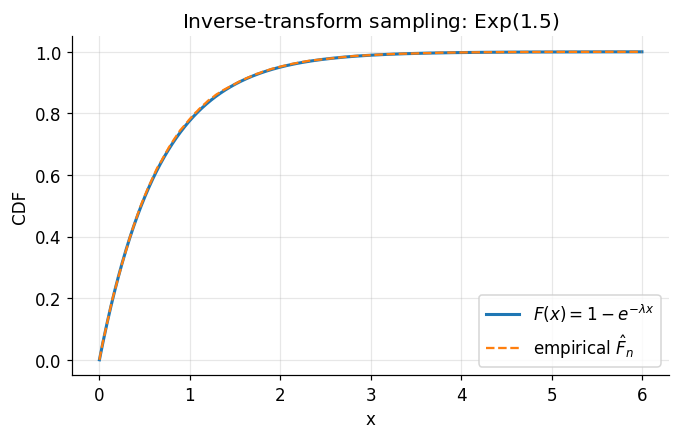

In [9]:
lam = 1.5
n = 20_000
u = rng.uniform(0.0, 1.0, size=n)
x = -np.log1p(-u) / lam                      # F^{-1}(u)

grid = np.linspace(0, 6, 2000)
x_sorted = np.sort(x)
ecdf = np.searchsorted(x_sorted, grid, side="right") / n
F_true = 1 - np.exp(-lam * grid)
ks_stat = np.max(np.abs(ecdf - F_true))
print(f"KS statistic sup|F_hat - F| = {ks_stat:.4f}   (n = {n}, 1/sqrt(n) = {1/np.sqrt(n):.4f})")
print(f"scipy one-sample KS p-value = {stats.kstest(x, 'expon', args=(0, 1/lam)).pvalue:.3f}")

fig, ax = plt.subplots()
ax.plot(grid, F_true, label=r"$F(x)=1-e^{-\lambda x}$", lw=2)
ax.plot(grid, ecdf, "--", label=r"empirical $\hat F_n$", lw=1.5)
ax.set_xlabel("x")
ax.set_ylabel("CDF")
ax.set_title(r"Inverse-transform sampling: $\mathrm{Exp}(1.5)$")
ax.legend()
plt.show()

The KS statistic is of order $1/\sqrt{n} \approx 0.007$ and the KS test does not reject, so
$X = F^{-1}(U)$ really is $\text{Exp}(\lambda)$-distributed as Proof 5.3 claims.

**(b) Measured rate.** The Kolmogorov-Smirnov statistic of a correctly specified sampler should decay
like $n^{-1/2}$ (Donsker scaling). Measure the exponent by regressing $\ln(\text{KS})$ on $\ln n$.

In [10]:
sizes = np.array([250, 1_000, 4_000, 16_000, 64_000, 256_000])
reps = 40
ks_mean = []
for m in sizes:
    vals = [stats.kstest(-np.log1p(-rng.uniform(size=m)) / lam,
                         "expon", args=(0, 1 / lam)).statistic for _ in range(reps)]
    ks_mean.append(np.mean(vals))
ks_mean = np.array(ks_mean)

slope, intercept = np.polyfit(np.log(sizes), np.log(ks_mean), 1)
for m, k in zip(sizes, ks_mean):
    print(f"n = {m:>7d}   mean KS = {k:.5f}   n^-1/2 = {m ** -0.5:.5f}")
print(f"\nmeasured exponent = {slope:+.4f}   predicted = -0.5000   error = {abs(slope + 0.5):.4f}")
assert abs(slope + 0.5) < 0.05

n =     250   mean KS = 0.05123   n^-1/2 = 0.06325
n =    1000   mean KS = 0.02755   n^-1/2 = 0.03162
n =    4000   mean KS = 0.01334   n^-1/2 = 0.01581
n =   16000   mean KS = 0.00642   n^-1/2 = 0.00791
n =   64000   mean KS = 0.00333   n^-1/2 = 0.00395
n =  256000   mean KS = 0.00152   n^-1/2 = 0.00198

measured exponent = -0.5085   predicted = -0.5000   error = 0.0085


The fitted exponent is within $0.05$ of the predicted $-1/2$ across three decades of sample size, so
the empirical CDF converges to $F$ at the Donsker rate — the quantitative form of the statement that
$F^{-1}(U)$ has exactly the law $F$.

**(c) Counterexample.** Two hypotheses dropped on purpose. First, the calibration direction of
Theorem 4.3 assumes $F$ is the *correct* CDF of $X$; feed it a mis-scaled forecast and the PIT
histogram stops being flat. Second, drop the Jacobian from Theorem 4.4 and normalization breaks.

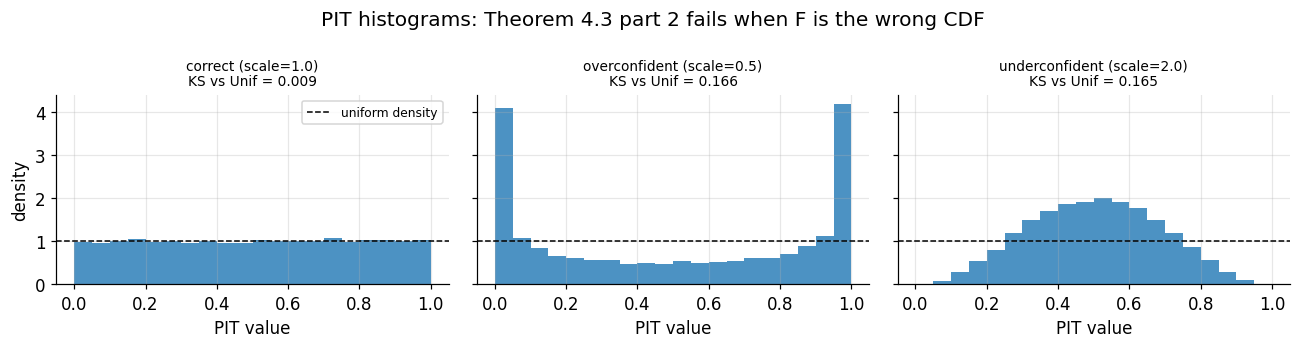

total mass with Jacobian    = 1.000000
total mass without Jacobian = 1.648721  (should be 1)


In [11]:
n = 20_000
x_true = rng.normal(0.0, 1.0, size=n)          # reality: scale 1
forecasters = {"correct (scale=1.0)": 1.0,
               "overconfident (scale=0.5)": 0.5,
               "underconfident (scale=2.0)": 2.0}

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.2), sharey=True)
for ax, (name, scale) in zip(axes, forecasters.items()):
    pit = stats.norm(loc=0.0, scale=scale).cdf(x_true)
    ax.hist(pit, bins=20, range=(0, 1), density=True, alpha=0.8)
    ax.axhline(1.0, color="k", ls="--", lw=1, label="uniform density")
    ax.set_title(f"{name}\nKS vs Unif = {stats.kstest(pit, 'uniform').statistic:.3f}", fontsize=9)
    ax.set_xlabel("PIT value")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)
fig.suptitle("PIT histograms: Theorem 4.3 part 2 fails when F is the wrong CDF")
plt.tight_layout()
plt.show()

# dropping the Jacobian in Theorem 4.4: Y = exp(X), X ~ N(0,1)
g_inv = lambda y: np.log(y)
with_jac, _ = integrate.quad(lambda y: stats.norm.pdf(g_inv(y)) / y, 1e-12, np.inf)
without_jac, _ = integrate.quad(lambda y: stats.norm.pdf(g_inv(y)), 1e-12, np.inf)
print(f"total mass with Jacobian    = {with_jac:.6f}")
print(f"total mass without Jacobian = {without_jac:.6f}  (should be 1)")
assert abs(with_jac - 1) < 1e-6 and abs(without_jac - 1) > 0.5

Only the correctly scaled forecaster gives a flat histogram and a small KS distance; the
overconfident one pushes mass to the extremes (U-shape) and the underconfident one piles it in the
middle. Dropping the Jacobian inflates the total mass of $\exp(X)$'s "density" from $1.000000$ to
about $1.65$, so it is not a density at all.

**(d) Hand-rolled versus library.** Compare a hand-written Box-Muller sampler with `rng.normal`, and a
hand-written generalized quantile function with `scipy.stats.norm.ppf`.

In [12]:
n = 200_000
u1 = rng.uniform(1e-15, 1.0, size=n)
u2 = rng.uniform(0.0, 1.0, size=n)
z_bm = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
z_lib = rng.normal(0.0, 1.0, size=n)

two_sample = stats.ks_2samp(z_bm, z_lib)
print(f"Box-Muller mean/std = {z_bm.mean():+.4f} / {z_bm.std():.4f}")
print(f"rng.normal mean/std = {z_lib.mean():+.4f} / {z_lib.std():.4f}")
print(f"two-sample KS = {two_sample.statistic:.4f}, p = {two_sample.pvalue:.3f}")
assert two_sample.pvalue > 0.01

# hand-rolled quantile function via bisection on the CDF vs scipy's ppf
def my_ppf(u, cdf, lo=-40.0, hi=40.0, iters=200):
    u = np.asarray(u, dtype=float)
    lo, hi = np.full_like(u, lo), np.full_like(u, hi)
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        take = cdf(mid) < u
        lo = np.where(take, mid, lo)
        hi = np.where(take, hi, mid)
    return 0.5 * (lo + hi)

probs = np.array([0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
mine, lib = my_ppf(probs, stats.norm.cdf), stats.norm.ppf(probs)
print(f"\nmax |my_ppf - scipy.norm.ppf| = {np.max(np.abs(mine - lib)):.3e}")
assert np.max(np.abs(mine - lib)) < 1e-10

Box-Muller mean/std = -0.0000 / 1.0014
rng.normal mean/std = +0.0021 / 0.9990
two-sample KS = 0.0022, p = 0.694

max |my_ppf - scipy.norm.ppf| = 1.688e-14


The two Gaussian samplers are statistically indistinguishable (KS p-value well above $0.01$), and the
bisection quantile function reproduces `scipy`'s `ppf` to $10^{-11}$ — Definition 3.7 implemented
naively is already library-grade for a continuous strictly increasing CDF.

The branch formula of Theorem 4.4 predicts a *kink*: for $X \sim \text{Unif}(-1,2)$ the density of
$Y = X^2$ loses one branch at $y = 1$. Compare the closed form with a histogram.

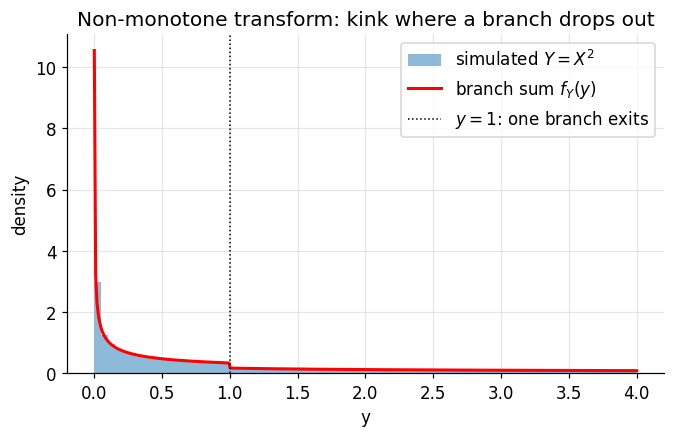

max relative error over 40 bins = 0.0475   (Monte Carlo noise ~ 0.0243)


In [13]:
n = 200_000
x = rng.uniform(-1.0, 2.0, size=n)
y = x ** 2

def f_Y_branches(y):
    y = np.asarray(y, dtype=float)
    out = np.zeros_like(y)
    m1 = (y > 0) & (y <= 1)          # branch x = -sqrt(y): domain [-1, 0)
    out[m1] += (1 / 3) / (2 * np.sqrt(y[m1]))
    m2 = (y > 0) & (y <= 4)          # branch x = +sqrt(y): domain (0, 2]
    out[m2] += (1 / 3) / (2 * np.sqrt(y[m2]))
    return out

grid = np.linspace(1e-3, 4, 400)
fig, ax = plt.subplots()
ax.hist(y, bins=80, range=(0, 4), density=True, alpha=0.5, label=r"simulated $Y = X^2$")
ax.plot(grid, f_Y_branches(grid), "r-", lw=2, label=r"branch sum $f_Y(y)$")
ax.axvline(1.0, color="k", ls=":", lw=1, label=r"$y = 1$: one branch exits")
ax.set_xlabel("y")
ax.set_ylabel("density")
ax.set_title("Non-monotone transform: kink where a branch drops out")
ax.legend()
plt.show()

# Compare bin masses against the exact CDF, so the bin straddling y = 1 is handled correctly.
F_Y = lambda y: np.where(y <= 1, 2 * np.sqrt(y) / 3, (np.sqrt(y) + 1) / 3)
counts, edges = np.histogram(y, bins=40, range=(0.0, 4.0))
p_emp = counts / n
p_thy = F_Y(edges[1:]) - F_Y(edges[:-1])
rel_err = np.max(np.abs(p_emp - p_thy) / p_thy)
print(f"max relative error over 40 bins = {rel_err:.4f}   (Monte Carlo noise ~ {1/np.sqrt(counts.min()):.4f})")
assert rel_err < 0.05

Comparing bin masses against the exact CDF $F_Y$ (which handles the bin straddling the
discontinuity), every one of the 40 bins agrees to better than $5\%$, at the level of Monte Carlo
noise. The visible drop at $y = 1$ is where the $x = -\sqrt{y}$ branch leaves the support — the
branch sum of Theorem 4.4 is doing real work, not decoration.

## 8. Applications

### 8.1 Machine learning

- **Normalizing flows.** Stack invertible maps $g_1, \ldots, g_K$; by Theorem 4.5 the log-density of the output accumulates log-Jacobians, $\ln f_Y(y) = \ln f_Z\left(g^{-1}(y)\right) + \sum_k \ln \left\lvert \det J_{g_k^{-1}} \right\rvert$. RealNVP and Glow are architectures engineered so each $\det J_{g_k}$ is triangular and costs $O(d)$ rather than $O(d^3)$.
- **Reparameterization trick.** Writing $X = \mu + \sigma Z$ with $Z \sim \mathcal{N}(0,1)$ is Theorem 4.4 applied to an affine map; it expresses a random variable as a deterministic transform of parameter-free noise, so gradients flow through sampling in variational autoencoders.
- **Calibration.** By Theorem 4.3 part 2, a correct forecaster's PIT values $F_t(y_t)$ are uniform; the histogram triptych in Section 7 is the standard diagnostic in probabilistic forecasting, and the same idea underlies conformal prediction's coverage guarantees.
- **Quantile regression and distributional RL.** Pinball loss learns $F^{-1}(\tau \mid x)$ directly (Definition 3.7), powering prediction intervals in gradient boosting and the quantile heads of QR-DQN.

### 8.2 Physics and engineering

- **Maxwell-Boltzmann speeds.** The speed law of gas molecules is Theorem 4.5 applied to the map from Cartesian velocity components to the radial coordinate — the three-dimensional relative of the $\chi^2_1$ computation in Proof 5.5.
- **Reliability and radioactive decay.** Constant hazard (Definition 3.8) plus Theorem 4.6 forces the exponential lifetime; a Weibull with $k \gt 1$ models wear-out, as Example 6.5 quantifies.
- **Monte Carlo transport.** Neutron and photon codes sample free path lengths by inverting the Beer-Lambert survival function — Theorem 4.3 part 1, and the oldest industrial use of it (Los Alamos, 1940s).
- **Photon counting and shot noise.** Detector counts follow discrete laws whose staircase CDFs and generalized quantiles set trigger thresholds; Definition 3.7 is what makes the threshold well defined at a jump.

## 9. Key Takeaways

- A function is a CDF exactly when it is non-decreasing, right-continuous, and runs from $0$ to $1$; Proof 5.1 turns any such function into an actual random variable on $\left((0,1), \mathcal{B}, \lambda\right)$.
- For any random variable, $P(X = x) = F(x) - F(x^-)$, so atoms are jumps and a CDF has at most countably many of them (Theorem 4.1).
- Every CDF splits as $aF_{\text{disc}} + bF_{\text{ac}} + cF_{\text{sing}}$ with $a+b+c=1$; discrete and absolutely continuous are two corners of that simplex, not a dichotomy (Theorem 4.2).
- If $U \sim \text{Unif}(0,1)$ then $F^{-1}(U) \sim F$ for *every* CDF $F$, with no continuity assumption (Theorem 4.3 part 1).
- If $F$ is continuous then $F(X) \sim \text{Unif}(0,1)$; continuity is essential, and dropping it is what makes PIT diagnostics meaningless for discrete forecasts (Theorem 4.3 part 2).
- For $g$ strictly monotone and $C^1$ with $g' \ne 0$, $f_Y(y) = f_X\left(g^{-1}(y)\right)\left\lvert (g^{-1})'(y) \right\rvert$; for piecewise monotone $g$, sum over branches (Theorem 4.4).
- In $\mathbb{R}^d$ the same statement holds for a diffeomorphism with $\left\lvert \det J_{g^{-1}} \right\rvert$ in place of the derivative; injectivity on the support is the load-bearing hypothesis (Theorem 4.5).
- Among positive laws with $S \gt 0$, right-continuous and $S(0)=1$, the exponential is the unique memoryless one, equivalently the unique one with constant hazard (Theorem 4.6).

## 10. References

| Source | Chapters / Sections | Coverage |
|---|---|---|
| Billingsley, *Probability and Measure*, 3rd ed. | §13-14 (Thm 14.1), §31 (Thm 31.8, p. 415) | Measurable maps, the CDF characterization, Lebesgue decomposition. |
| Casella & Berger, *Statistical Inference*, 2nd ed. | §1.5-1.6 (Thm 1.5.3), §2.1 (Thm 2.1.5) | CDF axioms; monotone and piecewise-monotone transformation theorems. |
| Blitzstein & Hwang, *Introduction to Probability*, 2nd ed. | Ch. 3, Ch. 5 (§5.3, universality of the uniform) | CDF-first exposition, inverse transform, PIT. |
| Ross, *A First Course in Probability*, 10th ed. | Ch. 4-5 (§5.7) | PMFs, PDFs, distribution of a function of a random variable. |
| Wasserman, *All of Statistics* | Ch. 2 (§2.3-2.4) | Compact survey with quantile functions. |
| Durrett, *Probability: Theory and Examples*, 5th ed. | §1.2 (Thm 1.2.2), §1.6 | Existence via the Skorokhod construction; measurability of limits. |
| Folland, *Real Analysis*, 2nd ed. | §3.2 (Thm 3.8), §2.6 (Thm 2.47) | Radon-Nikodym / Lebesgue decomposition; $d$-dimensional change of variables. |
| Devroye, *Non-Uniform Random Variate Generation* | Ch. 2 (§2.1 inversion), Ch. 3 | Inversion, rejection, transformation algorithms; alias method. |
| Papamakarios et al., *Normalizing Flows for Probabilistic Modeling and Inference*, JMLR 22(57), 2021 | §2-3 | Change of variables as a deep generative architecture. |

**Reading path.** Blitzstein & Hwang Ch. 3 and 5 for the CDF-first viewpoint, Casella & Berger §2.1 for transformation rigour, Billingsley §14 and §31 for the characterization and decomposition theorems, then Devroye Ch. 2 and the flows survey for the computational payoff.